<h2 style="
background-color:#F8D7DA;
color:black;
padding:10px;
border-radius:8px;
font-weight:bold;
font-style:italic;
">
Task 2: Descriptive Transactional Analysis
</h2>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("cleaned_jp_morgan.csv")

In [9]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month
0,3,CUST2412,ACC80131,loan,withdrawal,Personal Loan,Firm C,West,Manager 3,2023-08-06,33759.69057,126486.40830,0.225824,611,89,2023,8
1,32,CUST1467,ACC74631,current,withdrawal,Home Loan,Firm D,North,Manager 2,2023-11-08,69319.19933,24834.76291,0.335717,817,174,2023,11
2,9,CUST2699,ACC39482,loan,withdrawal,Credit Card,Firm D,West,Manager 4,2024-05-15,42831.48483,123007.43530,0.572453,332,31,2024,5
3,42,CUST9535,ACC82947,current,withdrawal,Home Loan,Firm A,South,Manager 4,2023-04-30,70903.79697,73073.64225,0.571993,626,92,2023,4
4,166,CUST7459,ACC39500,credit,payment,Home Loan,Firm D,South,Manager 4,2023-02-16,21948.97355,113405.32820,0.380675,411,13,2023,2


### **Convert Transaction Date**

In [11]:

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

**<h3 style="color:blue;">2.1 Calculate Monthly Summary of Credits, Debits and Net Transaction Volume.</h3>**

In [14]:
# Ensure amounts are numeric
df["TransactionAmount"] = pd.to_numeric(df["TransactionAmount"], errors='coerce')
# Clean transaction types of any hidden spaces
df["TransactionType"] = df["TransactionType"].astype(str).str.strip()

In [15]:
#  Create Year and Month helpers
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month

In [16]:
# Categorize Explicitly
df.loc[df["TransactionType"] == "deposit", 'Flow_Type'] = "Credit"
df.loc[df["TransactionType"] == "withdrawal", 'Flow_Type'] = "Debit"
df.loc[df["TransactionType"] == "payment", 'Flow_Type'] = "Debit"
df.loc[df["TransactionType"] == "transfer", 'Flow_Type'] = "Debit"

### **By Monthly Calculation**

In [17]:

#  Group and Calculate
# This creates a table with Year and Month as rows, and Credit/Debit as columns
monthly_summary = df.groupby(['Year', 'Month', 'Flow_Type'])['TransactionAmount'].sum().unstack(fill_value=0)

# Calculate Net Transaction Volume (Standard Credit - Debit)
monthly_summary['Net_Transaction_Volume'] = monthly_summary['Credit'] - monthly_summary['Debit']

#  View the Results
print(monthly_summary)

Flow_Type          Credit         Debit  Net_Transaction_Volume
Year Month                                                     
2023 1      586442.427030  2.219688e+06           -1.633246e+06
     2      788091.358440  1.977725e+06           -1.189633e+06
     3      568405.450700  1.906988e+06           -1.338583e+06
     4      593836.810010  2.115393e+06           -1.521556e+06
     5      729309.615730  1.867728e+06           -1.138418e+06
     6      803711.145215  1.406903e+06           -6.031924e+05
     7      793971.625099  1.653093e+06           -8.591216e+05
     8      880993.233920  1.270715e+06           -3.897213e+05
     9      699282.350630  1.416407e+06           -7.171250e+05
     10     789767.383366  2.363573e+06           -1.573805e+06
     11     789084.936660  2.086903e+06           -1.297818e+06
     12     202890.501930  1.101810e+06           -8.989193e+05
2024 1      335829.396102  1.006188e+06           -6.703587e+05
     2      507414.026400  1.444953e+06 

### **By Yearly Calculation**

In [18]:
# Group by Year to calculate totals
# Unstack moves Credit/Debit into their own columns
yearly_summary = df.groupby(["Year", "Flow_Type"])["TransactionAmount"].sum().unstack(fill_value=0)

#  Calculate Net Transaction Volume (Credit - Debit)
yearly_summary["Net_Transaction_Volume"] = yearly_summary["Credit"] - yearly_summary["Debit"]

#  Format the output
yearly_summary = yearly_summary.reset_index()

# Display the results
print(yearly_summary)

Flow_Type  Year        Credit         Debit  Net_Transaction_Volume
0          2023  8.225787e+06  2.138693e+07           -1.316114e+07
1          2024  2.238946e+06  9.017640e+06           -6.778694e+06


**<h3 style="color:blue;">2.2 **Plot trends in total credits vs. debits over time.</h3>**

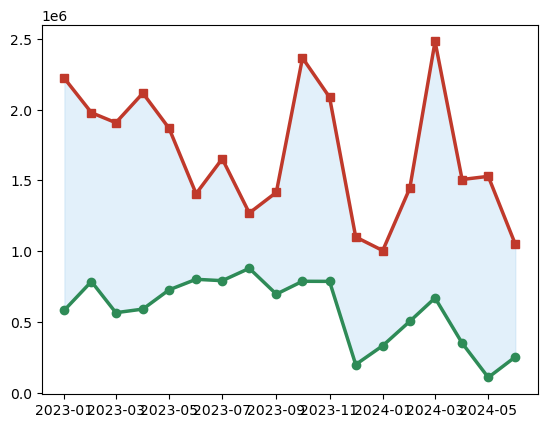

In [25]:
plt.plot(monthly_trend.index, monthly_trend["Credit"],
         marker="o",
         linewidth=2.5,
         label="Total Credits",
         color="#2E8B57")      # Sea Green

plt.plot(monthly_trend.index, monthly_trend["Debit"],
         marker="s",
         linewidth=2.5,
         label="Total Debits",
         color="#C0392B")      # Dark Red

plt.fill_between(monthly_trend.index,
                 monthly_trend["Credit"],
                 monthly_trend["Debit"],
                 color="#AED6F1",
                 alpha=0.35,
                 label="Net Volume Gap")

**<h3 style="color:blue;">2.3 Identify top and bottom performing accounts based on net inflow.</h3>**

In [28]:
# Calculate Net Inflow for Each Account

In [29]:


# Create a summary of total Credits and Debits for every Account
net_inflow_summary = (
    df.groupby(["AccountID", "Flow_Type"])["TransactionAmount"]
      .sum()
      .unstack(fill_value=0)
)

# Calculate Net Inflow
net_inflow_summary["Net_Inflow"] = (
    net_inflow_summary["Credit"] -
    net_inflow_summary["Debit"]
)

# Retrieve the Top and Bottom Performing Accounts
top_accounts = net_inflow_summary.nlargest(5, "Net_Inflow")
bottom_accounts = net_inflow_summary.nsmallest(5, "Net_Inflow")

# Display Results
print("=" * 65)
print("Top 5 Performing Accounts (Highest Net Inflow)")
print("=" * 65)
print(top_accounts[["Net_Inflow"]])

print("\n" + "=" * 65)
print("Bottom 5 Performing Accounts (Lowest Net Inflow)")
print("=" * 65)
print(bottom_accounts[["Net_Inflow"]])

Top 5 Performing Accounts (Highest Net Inflow)
Flow_Type     Net_Inflow
AccountID               
ACC54589   225122.495180
ACC67713   189071.785288
ACC74631   150954.104630
ACC87602   150860.567520
ACC22036   145164.795582

Bottom 5 Performing Accounts (Lowest Net Inflow)
Flow_Type     Net_Inflow
AccountID               
ACC18140  -458219.210460
ACC55331  -448188.410346
ACC51593  -414370.119240
ACC11285  -373189.528410
ACC81631  -342531.377190


**<h3 style="color:blue;">2.4 Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.</h3>**

In [30]:
# Sort by Account and Transaction Date
df = df.sort_values(by=["AccountID", "TransactionDate"])

# Calculate the gap between consecutive transactions
df["PrevDate"] = df.groupby("AccountID")["TransactionDate"].shift(1)
df["GapDays"] = (df["TransactionDate"] - df["PrevDate"]).dt.days

# Find the maximum gap for each account
dormant_account = df.groupby("AccountID")["GapDays"].max().reset_index()

# Flag accounts based on the maximum gap
dormant_account["Status"] = dormant_account["GapDays"].apply(
    lambda x: "Inactive/Dormant" if x >= 60 else "Active"
)

# Display only dormant accounts
flagged_accounts = dormant_account[dormant_account["Status"] == "Inactive/Dormant"]

print(flagged_accounts)

    AccountID  GapDays            Status
1    ACC10996    161.0  Inactive/Dormant
2    ACC11062    125.0  Inactive/Dormant
3    ACC11188    208.0  Inactive/Dormant
4    ACC11285     79.0  Inactive/Dormant
6    ACC12182    215.0  Inactive/Dormant
..        ...      ...               ...
188  ACC96868    197.0  Inactive/Dormant
189  ACC97225    331.0  Inactive/Dormant
190  ACC97411    151.0  Inactive/Dormant
191  ACC99117    121.0  Inactive/Dormant
193  ACC99549    232.0  Inactive/Dormant

[164 rows x 3 columns]
